In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
import json
from glob import glob
import re
import shutil
import matplotlib.pyplot as plt
import umap.umap_ as umap
from sklearn.preprocessing import LabelEncoder

import numpy as np
import torch
from typing import List
from langchain_text_splitters import RecursiveCharacterTextSplitter
from tqdm import tqdm

**Предобработка**


Тексты после PyMuPDF

In [ ]:
input_folder = "updated_instructions"
output_folder = "cleaned_updated_instructions"
os.makedirs(output_folder, exist_ok=True)

# удаление номеров страниц в начале каждого блока "content", разделенного по страница
page_num_pattern = re.compile(r'^\s*(?:С\.\s*\d+|Страница\s*\d+)\s*[\r\n]+', flags=re.MULTILINE)
digit_pattern = re.compile(r'^\s*\d+\s*[\r\n]+', flags=re.MULTILINE)

bullet_pattern = re.compile(r'[\u2022\uF08D\uF0AD\uF0B7]')     # удаление всех bullets
dashline_pattern   = re.compile(r'(?m)^[\-–—]{2,}\s*$')      # строки из дефисов/тире
underscore_pattern = re.compile(r'_+')                      # подчёркивания

def remove_marks(obj):
    if isinstance(obj, str):
        return obj.replace("®", "").replace("©", "").replace("", "")
    elif isinstance(obj, list):
        return [remove_marks(item) for item in obj]
    elif isinstance(obj, dict):
        return {k: remove_marks(v) for k, v in obj.items()}
    return obj

for file_path in glob(os.path.join(input_folder, "*.json")):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    # удаление спец символов
    data = remove_marks(data)

    for section in data.get("text_sections", []):
        content = section.get("content", "")

        # удаление страниц и одиночных цифр
        content = page_num_pattern.sub("", content)
        content = digit_pattern.sub("", content)

        # удаление bullets
        content = bullet_pattern.sub("", content)

        # удаление линии из дефисов/тире
        content = dashline_pattern.sub("", content)

        # удаление подчёркивания
        content = underscore_pattern.sub("", content)

        # замена переносов строк на пробелы
        content = content.replace("\n", " ")

        # сжимание пробелы
        content = re.sub(r'\s+', ' ', content).strip()

        section["content"] = content

    # объединение всё в единый text
    combined = [s["content"] for s in data.pop("text_sections", [])]
    data["text"] = " ".join(combined)

    out_path = os.path.join(output_folder, os.path.basename(file_path))
    with open(out_path, 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

Тексты после OCR

In [ ]:
input_folder = "updated_ocr_instructions"
output_folder = "cleaned_ocr_instructions"
os.makedirs(output_folder, exist_ok=True)

# удаление шумов мусора
bullet_marker_pattern = re.compile(r'[\u2022\uF08D\uF0AD\uF0B7\*\&\|\'‘$]')
dashline_pattern = re.compile(r'(?m)^[\-–—]{2,}\s*$')  # строки из дефисов/тире
underscore_pattern = re.compile(r'_+')                 # подчёркивания "____"

# удаление ® и ©
def clean_marks(obj):
    if isinstance(obj, str):
        return obj.replace("®", "").replace("©", "")
    elif isinstance(obj, list):
        return [clean_marks(item) for item in obj]
    elif isinstance(obj, dict):
        return {k: clean_marks(v) for k, v in obj.items()}
    else:
        return obj

for file_path in glob(os.path.join(input_folder, "*.json")):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = clean_marks(json.load(f))

    parts = []
    for section in data.get("ocr_text_sections", []):
        txt = section.get("text", "")

        #  удаление маркеров и буллетов
        txt = bullet_marker_pattern.sub('', txt)

        #  удаление строк из дефисов
        txt = dashline_pattern.sub('', txt)

        #  удаление подчёркиваний
        txt = underscore_pattern.sub('', txt)

        # удаление переносов строк
        txt = txt.replace("\n", " ")

        # жимаем пробелы
        txt = re.sub(r'\s+', ' ', txt).strip()

        parts.append(txt)


    full_text = " ".join(parts)

    output_data = {k: v for k, v in data.items() if k != "ocr_text_sections"}
    output_data["text"] = full_text

    out_path = os.path.join(output_folder, os.path.basename(file_path))
    with open(out_path, 'w', encoding='utf-8') as f:
        json.dump(output_data, f, ensure_ascii=False, indent=2)

Объединение папок

In [ ]:
folder1 = "cleaned_updated_instructions"
folder2 = "cleaned_ocr_instructions"
output_folder = "cleaned_instructions"

os.makedirs(output_folder, exist_ok=True)

for source_folder in [folder1, folder2]:
    for file_path in glob(os.path.join(source_folder, "*.json")):
        filename = os.path.basename(file_path)
        out_path = os.path.join(output_folder, filename)
        shutil.copyfile(file_path, out_path)


total_files = len(glob(os.path.join(output_folder, "*.json")))
print(f"Объединено файлов: {total_files}")

Объединено файлов: 560


**Информация о длине текстов**

Файлов: 560
Средняя длина инструкции: 30858.64 символов
Медиана длины: 28225.00 символов
Мин. длина: 703 символов
Макс. длина: 89808 символов
Стандартное отклонение: 16341.22
Инструкций длиной > 5000: 546 (97.5%)


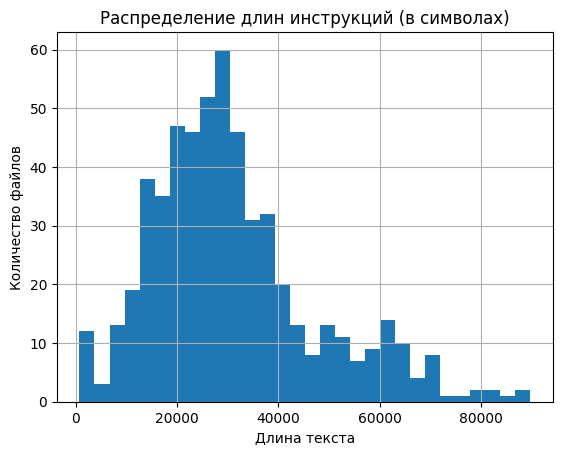

In [ ]:
folder = "cleaned_instructions"
lengths = []

for file_path in glob(os.path.join(folder, "*.json")):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        text = data.get("text", "")
        lengths.append(len(text))

lengths = np.array(lengths)


print(f"Файлов: {len(lengths)}")
print(f"Средняя длина инструкции: {lengths.mean():.2f} символов")
print(f"Медиана длины: {np.median(lengths):.2f} символов")
print(f"Мин. длина: {lengths.min()} символов")
print(f"Макс. длина: {lengths.max()} символов")
print(f"Стандартное отклонение: {lengths.std():.2f}")

# доля очень длинных текстов
threshold = 5000
long_docs = np.sum(lengths > threshold)
print(f"Инструкций длиной > {threshold}: {long_docs} ({(long_docs / len(lengths)) * 100:.1f}%)")

plt.hist(lengths, bins=30)
plt.title("Распределение длин инструкций (в символах)")
plt.xlabel("Длина текста")
plt.ylabel("Количество файлов")
plt.grid(True)
plt.show()

**Деление на чанки**

In [ ]:
input_folder = "cleaned_instructions"
output_folder = "chunked_instructions"

os.makedirs(output_folder, exist_ok=True)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1800,
    chunk_overlap=200
)

total_chunks = 0
chunk_lengths = []

for filename in tqdm(os.listdir(input_folder), desc="Прогресс"):
    if not filename.endswith(".json"):
        continue

    input_path = os.path.join(input_folder, filename)

    with open(input_path, "r", encoding="utf-8") as file:
        try:
            data = json.load(file)
        except json.JSONDecodeError:
            print(f"Ошибка чтения json: {filename}")
            continue

    text = data.get("text", "").strip()
    if not text:
        print(f"Пустой текст: {filename}")
        continue

    chunks = text_splitter.split_text(text)

    for i, chunk in enumerate(chunks):
        chunk_data = {
            "mnn": data.get("mnn", ""),
            "trade_name": data.get("trade_name", ""),
            "drug_id": data.get("drug_id", ""),
            "file_name": data.get("file_name", ""),
            "chunk_id": i,
            "text": chunk
        }

        chunk_filename = f"{data.get('drug_id', 'unknown')}_chunk_{i}.json"
        chunk_path = os.path.join(output_folder, chunk_filename)

        with open(chunk_path, "w", encoding="utf-8") as chunk_file:
            json.dump(chunk_data, chunk_file, ensure_ascii=False, indent=2)

        total_chunks += 1
        chunk_lengths.append(len(chunk))

In [ ]:
if chunk_lengths:
    avg_length = sum(chunk_lengths) / len(chunk_lengths)
    min_length = min(chunk_lengths)
    max_length = max(chunk_lengths)

print(f"\nВсего чанков: {total_chunks}")
print(f"Средняя длина чанка (символов): {avg_length:.2f}")
print(f"Минимальная длина чанка: {min_length}")
print(f"Максимальная длина чанка: {max_length}")


Всего чанков: 11008
Средняя длина чанка (символов): 1754.30
Минимальная длина чанка: 204
Максимальная длина чанка: 1800
